Churn means a customer stopped buying for a period.

🧠 Common definition:

A customer is churned if they haven't made a purchase in the last 6 months (or 180 days).

📌 You need:

InvoiceDate or last_purchase_date column

A fixed reference_date (e.g., the latest date in your dataset)

In [11]:
from google.colab import files
uploaded = files.upload()

Saving Online_retail.csv to Online_retail.csv


In [13]:
import os
os.listdir()

['.config', '.ipynb_checkpoints', 'sample_data', 'Online_retail.csv']

In [30]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
rfm_df = pd.read_csv('Online_retail.csv', encoding='ISO-8859-1')
rfm_df['InvoiceDate'] = pd.to_datetime(rfm_df['InvoiceDate'], dayfirst=False, errors='coerce')

In [18]:
reference_date = rfm_df['InvoiceDate'].max()

In [19]:
# Group by CustomerID to find the last purchase date
recency_info = rfm_df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_info['DaysSinceLastPurchase'] = (reference_date - recency_info['InvoiceDate']).dt.days

In [20]:
# Define Churn (180 days as threshold)
recency_info['Churn'] = recency_info['DaysSinceLastPurchase'].apply(lambda x: 1 if x > 180 else 0)

In [23]:
rfm1_df=pd.read_csv('/content/RFM1.csv')

In [24]:
#Merge churn labels with RFM features on 'CustomerID'
df = pd.merge(rfm1_df, recency_info[['CustomerID', 'Churn']], on='CustomerID', how='inner')

In [25]:
#Prepare feature matrix X and target vector y
X = df[['Recency', 'Frequency', 'Monetary']]
y = df['Churn']

In [26]:
#Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
#Initialize and train the Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [28]:
#Make predictions on test set
y_pred = gb_model.predict(X_test)
y_pred_proba = gb_model.predict_proba(X_test)[:, 1]

In [29]:
#Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.98      0.90       649
           1       0.89      0.42      0.58       219

    accuracy                           0.84       868
   macro avg       0.86      0.70      0.74       868
weighted avg       0.85      0.84      0.82       868

Confusion Matrix:
 [[638  11]
 [126  93]]
ROC AUC Score: 0.8435387072489463


In [31]:
#SHAP explanations (optional but useful for interpretability)
explainer = shap.Explainer(gb_model)
shap_values = explainer(X_test)

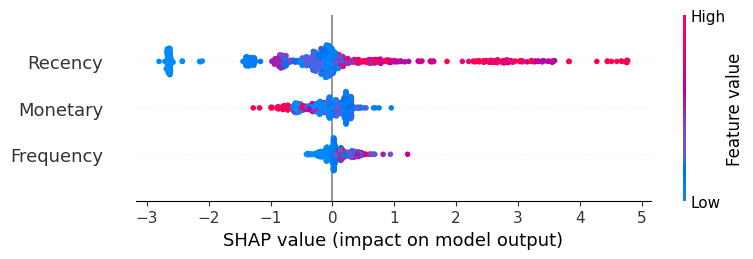

In [32]:
#Plot SHAP summary plot
shap.summary_plot(shap_values, X_test)

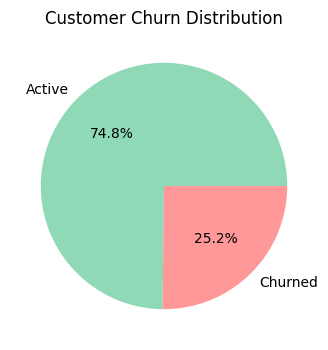

In [34]:
churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(churn_counts, labels=['Active', 'Churned'], autopct='%1.1f%%', colors=['#8fd9b6', '#ff9999'])
plt.title('Customer Churn Distribution')
plt.show()

In [35]:
# Example: new customer data
new_customer = [[30, 2, 50]]  # Recency=30 days, Frequency=2 purchases, Monetary=$50 spent

# Predict churn probability
churn_pred = gb_model.predict(new_customer)
print(churn_pred)  # Output: [1] or [0]

[0]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
